In [2]:

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ── Load Dataset ──
df = pd.read_csv("Housing.csv")
df["price_lakhs"] = df["price"] / 100000  # Convert to Lakhs

print("Dataset Shape:", df.shape)
print(df.head())


Dataset Shape: (545, 14)
      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  \
0              no             yes        2      yes        furnished   
1              no             yes        3       no        furnished   
2              no              no        2      yes   semi-furnished   
3              no             yes        3      yes        furnished   
4              no             yes        2       no        furnished   

   price_lakhs  
0       133.00  
1       122.50  
2       122.50  


House counts by price range:
price_range
0–25L       32
26–50L     318
51–75L     148
76–100L     39
>100L        8
Name: count, dtype: int64


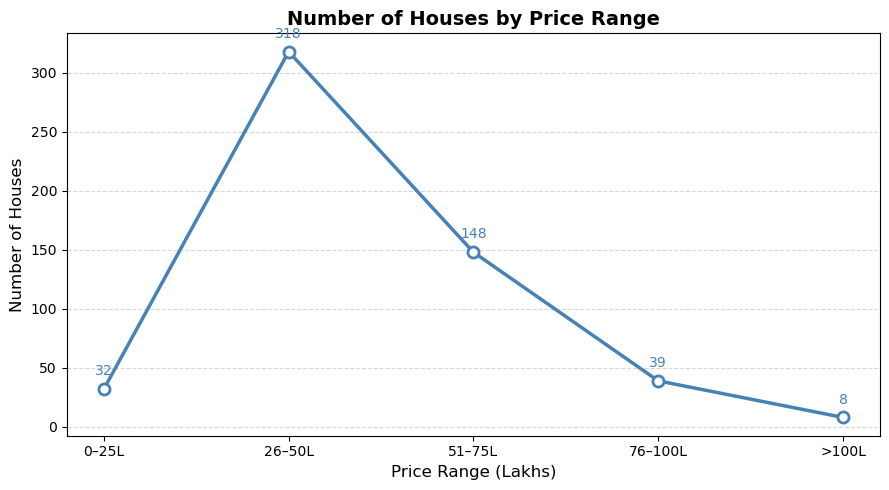

In [3]:
#Count houses in price ranges and visualize with a Line Chart
# Define price range bins (in Lakhs)
bins   = [0, 25, 50, 75, 100, float("inf")]
labels = ["0–25L", "26–50L", "51–75L", "76–100L", ">100L"]

df["price_range"] = pd.cut(df["price_lakhs"], bins=bins, labels=labels, right=True)
range_counts = df["price_range"].value_counts().sort_index()

print("\nHouse counts by price range:")
print(range_counts)

# Line Chart
plt.figure(figsize=(9, 5))
plt.plot(range_counts.index, range_counts.values, marker="o", color="steelblue",
         linewidth=2.5, markersize=8, markerfacecolor="white", markeredgewidth=2)
for x, y in zip(range_counts.index, range_counts.values):
    plt.annotate(str(y), (x, y), textcoords="offset points",
                 xytext=(0, 10), ha="center", fontsize=10, color="steelblue")
plt.title("Number of Houses by Price Range", fontsize=14, fontweight="bold")
plt.xlabel("Price Range (Lakhs)", fontsize=12)
plt.ylabel("Number of Houses", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("q1_price_range_line_chart.png", dpi=150)
plt.show()



Average price (Lakhs):
airconditioning
Without AC    41.92
With AC       60.13
Name: price_lakhs, dtype: float64


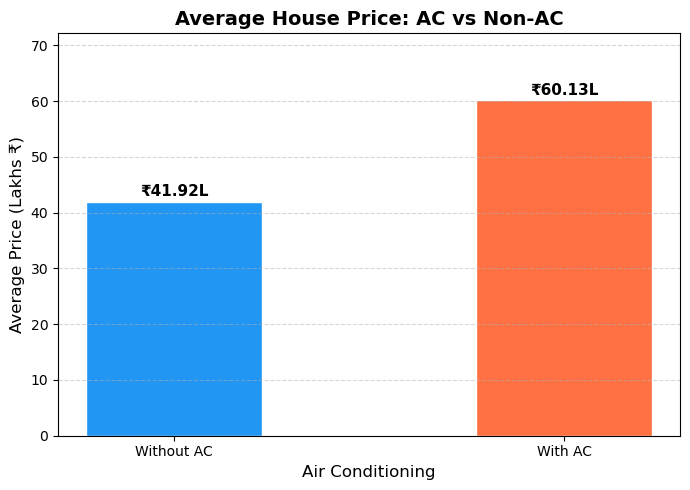

In [4]:
# Average house price for AC vs Non-AC – Bar Chart
avg_price_ac = df.groupby("airconditioning")["price_lakhs"].mean().round(2)
avg_price_ac.index = avg_price_ac.index.map({"yes": "With AC", "no": "Without AC"})

print("\nAverage price (Lakhs):")
print(avg_price_ac)

colors = ["#2196F3", "#FF7043"]
plt.figure(figsize=(7, 5))
bars = plt.bar(avg_price_ac.index, avg_price_ac.values, color=colors,
               width=0.45, edgecolor="white")
for bar, val in zip(bars, avg_price_ac.values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
             f"₹{val:.2f}L", ha="center", va="bottom", fontsize=11, fontweight="bold")
plt.title("Average House Price: AC vs Non-AC", fontsize=14, fontweight="bold")
plt.xlabel("Air Conditioning", fontsize=12)
plt.ylabel("Average Price (Lakhs ₹)", fontsize=12)
plt.ylim(0, avg_price_ac.values.max() * 1.2)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("q2_ac_avg_price_bar_chart.png", dpi=150)
plt.show()


Average price by parking slots:
parking
0    41.36
1    51.90
2    58.96
3    58.67
Name: price_lakhs, dtype: float64


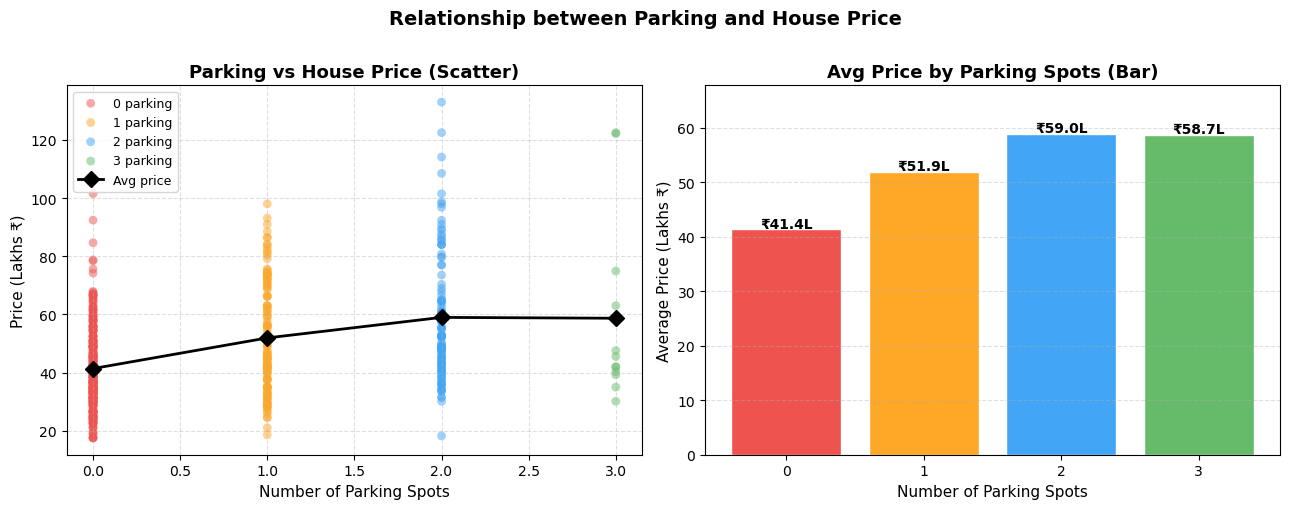

In [5]:
# Relationship between Parking spots and House Price
# Average price per parking count + scatter for all individual points
avg_by_parking = df.groupby("parking")["price_lakhs"].mean().round(2)

print("\nAverage price by parking slots:")
print(avg_by_parking)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scatter plot
scatter_colors = {0: "#EF5350", 1: "#FFA726", 2: "#42A5F5", 3: "#66BB6A"}
for p_val, grp in df.groupby("parking"):
    axes[0].scatter(grp["parking"], grp["price_lakhs"],
                    color=scatter_colors[p_val], alpha=0.5, label=f"{p_val} parking",
                    s=40, edgecolors="none")
axes[0].plot(avg_by_parking.index, avg_by_parking.values,
             color="black", marker="D", linewidth=2, markersize=8, label="Avg price")
axes[0].set_title("Parking vs House Price (Scatter)", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Number of Parking Spots", fontsize=11)
axes[0].set_ylabel("Price (Lakhs ₹)", fontsize=11)
axes[0].legend(fontsize=9)
axes[0].grid(linestyle="--", alpha=0.4)

# Bar chart of average price per parking count
axes[1].bar(avg_by_parking.index.astype(str), avg_by_parking.values,
            color=["#EF5350", "#FFA726", "#42A5F5", "#66BB6A"], edgecolor="white")
for i, (x, y) in enumerate(zip(avg_by_parking.index, avg_by_parking.values)):
    axes[1].text(i, y + 0.3, f"₹{y:.1f}L", ha="center", fontsize=10, fontweight="bold")
axes[1].set_title("Avg Price by Parking Spots (Bar)", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Number of Parking Spots", fontsize=11)
axes[1].set_ylabel("Average Price (Lakhs ₹)", fontsize=11)
axes[1].grid(axis="y", linestyle="--", alpha=0.4)
axes[1].set_ylim(0, avg_by_parking.max() * 1.15)

plt.suptitle("Relationship between Parking and House Price",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("q3_parking_vs_price.png", dpi=150, bbox_inches="tight")
plt.show()


 Price Gap Analysis:
  Houses (<5000 sqft, no prefarea)  → Count: 269,  Avg price: ₹38.28L
  Houses (>5000 sqft, with prefarea) → Count: 91, Avg price: ₹65.47L
  Price Gap: ₹27.19 Lakhs


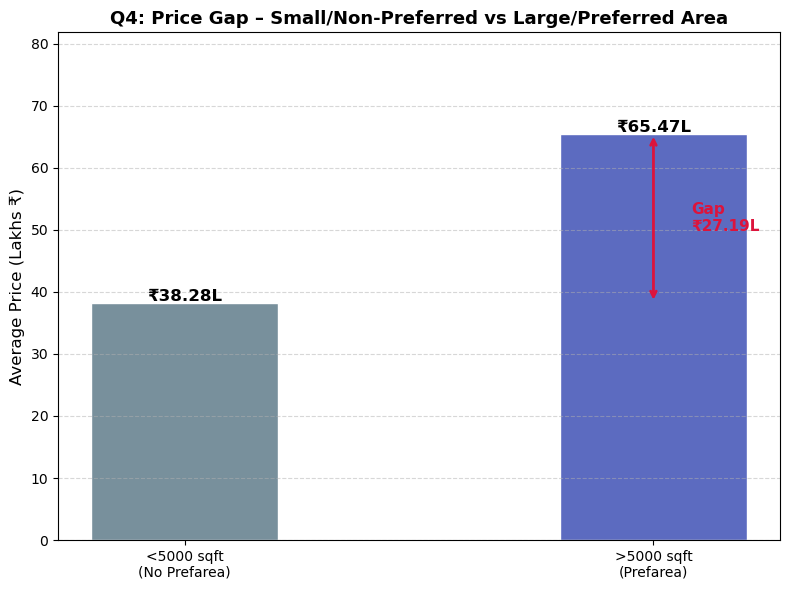

In [6]:
# Price gap between (<5000 sqft & no prefarea) vs (>5000 sqft & prefarea)
group_low  = df[(df["area"] < 5000) & (df["prefarea"] == "no")]
group_high = df[(df["area"] > 5000) & (df["prefarea"] == "yes")]

avg_low  = group_low["price_lakhs"].mean().round(2)
avg_high = group_high["price_lakhs"].mean().round(2)
gap      = round(avg_high - avg_low, 2)

print("\n Price Gap Analysis:")
print(f"  Houses (<5000 sqft, no prefarea)  → Count: {len(group_low)},  Avg price: ₹{avg_low}L")
print(f"  Houses (>5000 sqft, with prefarea) → Count: {len(group_high)}, Avg price: ₹{avg_high}L")
print(f"  Price Gap: ₹{gap} Lakhs")

# Grouped bar chart + gap annotation
labels_q4  = ["<5000 sqft\n(No Prefarea)", ">5000 sqft\n(Prefarea)"]
avg_prices = [avg_low, avg_high]
bar_colors = ["#78909C", "#5C6BC0"]

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.bar(labels_q4, avg_prices, color=bar_colors, width=0.4, edgecolor="white")
for bar, val in zip(bars, avg_prices):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f"₹{val}L", ha="center", fontsize=12, fontweight="bold")

# Annotate gap with a bracket arrow
ax.annotate("", xy=(1, avg_high), xytext=(1, avg_low),
            arrowprops=dict(arrowstyle="<->", color="crimson", lw=2))
ax.text(1.08, (avg_low + avg_high) / 2,
        f"Gap\n₹{gap}L", color="crimson", fontsize=11, fontweight="bold", va="center")

ax.set_title("Q4: Price Gap – Small/Non-Preferred vs Large/Preferred Area",
             fontsize=13, fontweight="bold")
ax.set_ylabel("Average Price (Lakhs ₹)", fontsize=12)
ax.set_ylim(0, avg_high * 1.25)
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("q4_price_gap.png", dpi=150)
plt.show()
